<a href="https://colab.research.google.com/github/manas-geo/My-City/blob/main/Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Create a Landsat Composite


[Landsat](https://www.usgs.gov/landsat-missions) satellites has been continuously observing the earth for over 40 years - making it an ideal choice for monitoring long term changes. For most parts of the world, the data is consistently available from 1990- onwards. Explore the data and create annual RGB composites for multiple time periods to see how your region of interest has changed.

The entire Landsat archive is available on Microsoft's [Planetary Computer Data Catalog]((https://planetarycomputer.microsoft.com/catalog)) and can be accessed freely. Your task is to access the [Landsat Collection 2 Level-2](https://planetarycomputer.microsoft.com/dataset/landsat-c2-l2) collection and use the techniques learnt in Module 1 to process the data and create annual RGB composites. You can try to create 2 composites - one for 2000 and another for 2025 to visualize how your area of interest has changed.


Notes:

- Data acces from Planetary Computer is largely similar to other STAC APIs but requires obtaining a signed url. This notebook provides the code snippets below to show the access pattern.
- The `landsat-c2-l2` collection contains images from all Landsat satellites. You will need to add a filter in your search query to select images from specific satellites, like `landsat-5`, `landsat-7` or `landsat-8`.
- Early years may not have enough images for your region. Adjust (or remove) the cloud filter to ensure you have 3-5 images for the year to create a cloud-free composite. Change the year if you do not find enough images.
- Landsat image bands have different scale and offsets. Look at the metadata of a STAC item to find the appropriate values.

----

Install and use the [`planetary_computer`](https://pypi.org/project/planetary-computer/) python package.

In [ ]:
import planetary_computer as pc

Accessing data from Planetary Computer is free but requires getting a Shared Access Signature (SAS) token and sign the URLs. The `planetary_computer` Python package provides a simple mechanism for signing the URLs using `sign()` function. Specify the `patch_url` parameter in `odc.stac.load()` function.

In [ ]:
ds = load(
    items,
    bands=['red', 'green', 'blue'],
    bbox=bbox,
    resolution=30,
    crs='utm',
    chunks={'x': 1024, 'y': 1024},  # Explicitly define chunk sizes
    patch_url=pc.sign,
    groupby='solar_day',
)

#Solution

#Step 1: Install Required Libraries

In [1]:
%%capture
!pip install -q pystac-client planetary-computer odc-stac geopandas rioxarray leafmap localtileserver

#Step 2: Import Libraries & Environment Setup

In [2]:
import os
import shutil
import pystac_client
import leafmap
from google.colab import output
from IPython.display import display, HTML
import planetary_computer as pc
import odc.stac
import geopandas as gpd
import rioxarray
import matplotlib.pyplot as plt

# 1. Enable third-party widgets for the swipe map
output.enable_custom_widget_manager()

# 2. CSS FIX: Forces the menu text to be black so it is readable in Colab
display(HTML("<style>.leaflet-control, .widget-html, .widget-dropdown select, .widget-readout { color: black !important; }</style>"))

# 3. Google Colab Fix: Opens the port for local files to display
if 'COLAB_RELEASE_TAG' in os.environ:
    os.environ['LOCALTILESERVER_CLIENT_PREFIX'] = f"{os.environ.get('COLAB_BACKEND_URL', '')}/"

#Step 3 Load ROI

In [3]:
# 1. Load your custom Kolkata ROI directly from your GitHub
github_raw_url = "https://raw.githubusercontent.com/manas-geo/My-City/main/Kolkata.geojson"
gdf = gpd.read_file(github_raw_url)

# 2. Extract the exact geometry (for searching) and bounding box (for downloading)
roi_geometry = gdf.geometry.iloc[0].__geo_interface__
bbox = list(gdf.total_bounds)

print(f"Region of Interest loaded successfully. Bounding Box: {bbox}")

Region of Interest loaded successfully. Bounding Box: [np.float64(88.23361486124828), np.float64(22.503018489870957), np.float64(88.41431105341297), np.float64(22.632938836575768)]


#Step 4: Connect to Planetary Computer STAC Catalog and Search Using the ROI

In [4]:
# 1. Connect to Planetary Computer STAC Catalog
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=pc.sign_inplace,
)

# 2. Search for Year 2000 (Filtering for ONLY Landsat 5)
search_2000 = catalog.search(
    collections=["landsat-c2-l2"],
    intersects=roi_geometry,
    datetime="2000-01-01/2000-12-31",
    query={
        "eo:cloud_cover": {"lt": 10},
        "platform": {"eq": "landsat-5"}
    }
)
items_2000 = search_2000.item_collection()
print(f"Found {len(items_2000)} cloud-free images for Landsat 5 (2000)")

# 3. Search for Year 2025 (Filtering for ONLY Landsat 8)
search_2025 = catalog.search(
    collections=["landsat-c2-l2"],
    intersects=roi_geometry,
    datetime="2025-01-01/2025-12-31",
    query={
        "eo:cloud_cover": {"lt": 10},
        "platform": {"eq": "landsat-8"}
    }
)
items_2025 = search_2025.item_collection()
print(f"Found {len(items_2025)} cloud-free images for Landsat 8 (2025)")

Found 14 cloud-free images for Landsat 5 (2000)
Found 13 cloud-free images for Landsat 8 (2025)


#Step 5: Define the Processing, Clipping, and Exporting Function

In [5]:
def process_multiband_clip(items, download_bbox, exact_geometry, output_filename):
    # 1. Explicitly define the 6 bands to download for BOTH satellites
    band_list = ['blue', 'green', 'red', 'nir08', 'swir16', 'swir22']

    # 2. Load the data
    ds = odc.stac.load(
        items,
        bands=band_list,
        bbox=download_bbox,
        resolution=30,
        crs='utm',
        chunks={'x': 1024, 'y': 1024},
        patch_url=pc.sign,
        groupby='solar_day'
    )

    # 3. Apply standard Landsat scale/offset to ALL bands
    multiband = ds[band_list].to_array(dim='band')
    scale = 0.0000275
    offset = -0.2
    multiband_scaled = (multiband * scale) + offset

    # 4. Calculate median composite (removes clouds)
    composite = multiband_scaled.median(dim='time')

    # 5. Clip exactly to the Kolkata polygon
    image_crs = ds.odc.crs
    gdf_projected = exact_geometry.to_crs(image_crs)
    composite = composite.rio.write_crs(image_crs)
    clipped = composite.rio.clip(gdf_projected.geometry, gdf_projected.crs, drop=True)

    # 6. Brightness Stretch
    clipped_stretched = (clipped / 0.25).clip(0, 1)

    # 7. Convert to 0-255 format, set background to transparent, and save
    clipped_255 = (clipped_stretched * 255).astype('uint8')
    clipped_255.rio.write_nodata(0, inplace=True)
    clipped_255.rio.to_raster(output_filename)

    return output_filename

#Step 6: Execute

In [6]:
print("Processing 6-band 2000 composite...")
file_2000 = process_multiband_clip(items_2000, bbox, gdf, "kolkata_6band_2000.tif")

print("Processing 6-band 2025 composite...")
file_2025 = process_multiband_clip(items_2025, bbox, gdf, "kolkata_6band_2025.tif")

print("Processing complete!")

Processing 6-band 2000 composite...
Processing 6-band 2025 composite...
Processing complete!


#Step 7: Plot

In [7]:
# 3. Initialize the map and explicitly add the Esri Satellite Basemap
m = leafmap.Map(center=[22.57, 88.36], zoom=12.4)
m.add_basemap("Esri.WorldTopoMap")

# 4. Add the 2000 Image as a toggleable layer with RGB bands
m.add_raster(
    file_2000,
    indexes=[3, 2, 1],
    vmin=0,
    vmax=255,
    nodata=0,
    layer_name='Kolkata 2000'
)

# 5. Add the 2025 Image as a toggleable layer with RGB bands
m.add_raster(
    file_2025,
    indexes=[3, 2, 1],
    vmin=0,
    vmax=255,
    nodata=0,
    layer_name='Kolkata 2025'
)

# 6. Zoom perfectly to your Kolkata shape and display
m.zoom_to_gdf(gdf)
display(m)

Map(center=[22.5682245, 88.3241695], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title…

In [8]:
# 3. Initialize the map WITH the Esri satellite basemap
m = leafmap.Map(center=[22.57, 88.36], zoom=12.4, basemap="Esri.WorldImagery")

# 4. Add the split-panel swipe map
# True color (Red, Green, Blue) is at indices [3, 2, 1] for BOTH images
m.split_map(
    left_layer=file_2000,
    right_layer=file_2025,
    left_args={'indexes': [3, 2, 1], 'vmin': 0, 'vmax': 255, 'nodata': 0},
    right_args={'indexes': [3, 2, 1], 'vmin': 0, 'vmax': 255, 'nodata': 0},
    left_label='Kolkata 2000',
    right_label='Kolkata 2025'
)

# 5. Zoom perfectly to your Kolkata shape and display
m.zoom_to_gdf(gdf)
display(m)

Map(center=[22.57, 88.36], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_o…

#Step 8: Comparison plot



Generating static side-by-side comparison...


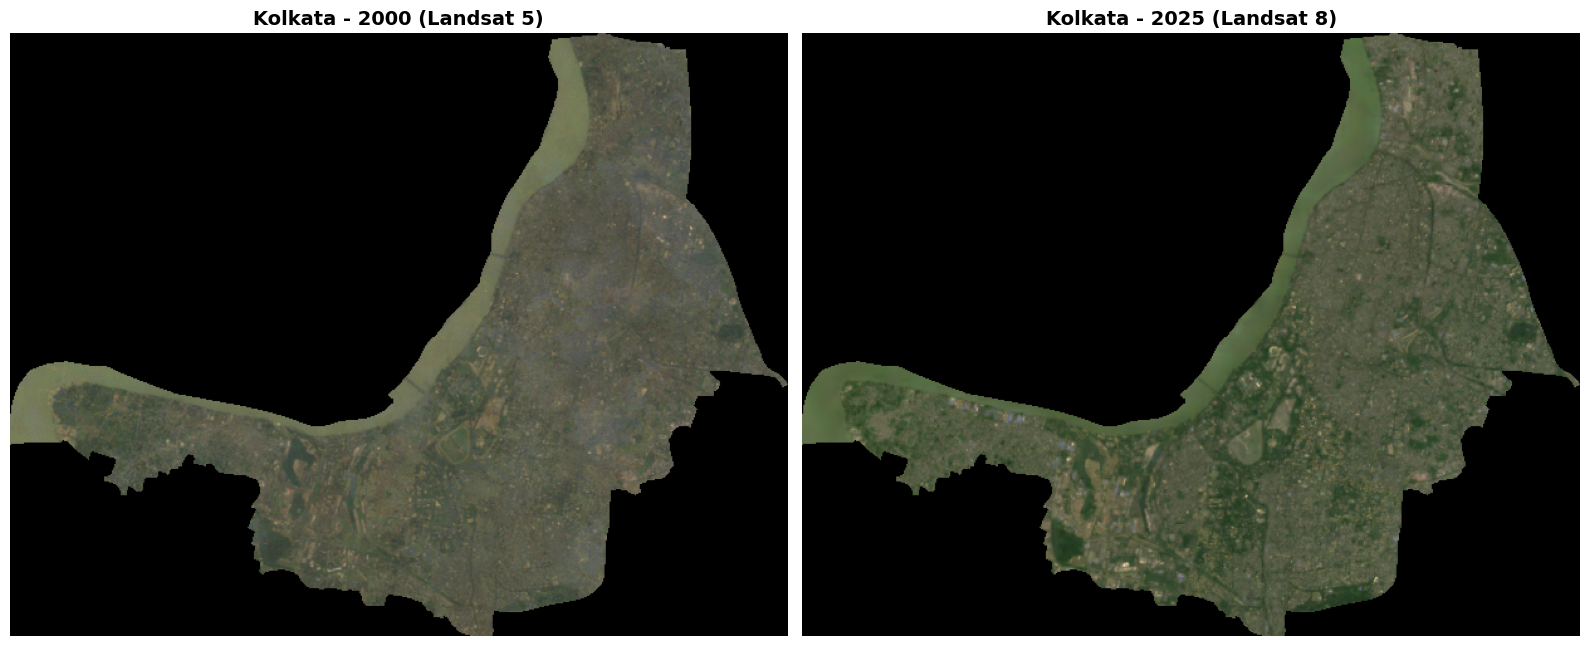

In [9]:
print("Generating static side-by-side comparison...")

# 1. Open the files and select ONLY the True Color RGB bands
# Python is 0-indexed. Our list was: 0=Blue, 1=Green, 2=Red.
# So to plot RGB, we slice the array and reorder to [2, 1, 0] for BOTH files.
rgb_2000 = rioxarray.open_rasterio(file_2000).isel(band=[2, 1, 0])
rgb_2025 = rioxarray.open_rasterio(file_2025).isel(band=[2, 1, 0])

# 2. Set up the plot
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 3. Plot 2000
axes[0].imshow(rgb_2000.transpose("y", "x", "band").values)
axes[0].set_title("Kolkata - 2000 (Landsat 5)", fontsize=14, fontweight='bold')
axes[0].axis("off")

# 4. Plot 2025
axes[1].imshow(rgb_2025.transpose("y", "x", "band").values)
axes[1].set_title("Kolkata - 2025 (Landsat 8)", fontsize=14, fontweight='bold')
axes[1].axis("off")

plt.tight_layout()
plt.show()

#Step 9: Save to Google Drive

In [10]:
from google.colab import drive
drive.mount('/content/drive')

drive_folder = '/content/drive/MyDrive/Earth_Engine_Assignment'
os.makedirs(drive_folder, exist_ok=True)

# 3. Copy the processed .tif files to your Google Drive
print(f"Saving {file_2000} to Drive...")
shutil.copy(file_2000, drive_folder)

print(f"Saving {file_2025} to Drive...")
shutil.copy(file_2025, drive_folder)

print(f"Success! Your files are safely saved in: {drive_folder}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving kolkata_6band_2000.tif to Drive...
Saving kolkata_6band_2025.tif to Drive...
Success! Your files are safely saved in: /content/drive/MyDrive/Earth_Engine_Assignment
